In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [16]:
#import the dataframe
dt = pd.read_csv('/Users/ayishahseimela/Downloads/car_prices.csv')
print(dt)

        year    make                model         trim       body  \
0       2015     Kia              Sorento           LX        SUV   
1       2015     Kia              Sorento           LX        SUV   
2       2014     BMW             3 Series   328i SULEV      Sedan   
3       2015   Volvo                  S60           T5      Sedan   
4       2014     BMW  6 Series Gran Coupe         650i      Sedan   
...      ...     ...                  ...          ...        ...   
558832  2015     Kia                 K900       Luxury      Sedan   
558833  2012     Ram                 2500  Power Wagon   Crew Cab   
558834  2012     BMW                   X5    xDrive35d        SUV   
558835  2015  Nissan               Altima        2.5 S      sedan   
558836  2014    Ford                F-150          XLT  SuperCrew   

       transmission                vin state  condition  odometer   color  \
0         automatic  5xyktca69fg566472    ca        5.0   16639.0   white   
1         automat

In [7]:
a = dataframe.info()
print(a)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB
None


In [8]:
#get info on the columns
b = dataframe.describe()
print(b)

                year      condition       odometer            mmr  \
count  558837.000000  547017.000000  558743.000000  558799.000000   
mean     2010.038927      30.672365   68320.017767   13769.377495   
std         3.966864      13.402832   53398.542821    9679.967174   
min      1982.000000       1.000000       1.000000      25.000000   
25%      2007.000000      23.000000   28371.000000    7100.000000   
50%      2012.000000      35.000000   52254.000000   12250.000000   
75%      2013.000000      42.000000   99109.000000   18300.000000   
max      2015.000000      49.000000  999999.000000  182000.000000   

        sellingprice  
count  558825.000000  
mean    13611.358810  
std      9749.501628  
min         1.000000  
25%      6900.000000  
50%     12100.000000  
75%     18200.000000  
max    230000.000000  


In [9]:
#chech null values 
c = dataframe.isnull().sum()
print(c)

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


In [11]:
d = dataframe['odometer'].mean().round(1)
print(d)

68320.0


In [21]:
#remove rows with missing crictical information
dt = dt.dropna(subset=['sellingprice', 'year', 'make', 'saledate', 'transmission', 'body'])

#converting data to numeric 
dt['sellingprice'] = pd.to_numeric(dt['sellingprice'], errors='coerce')
dt['odometer'] = pd.to_numeric(dt['odometer'], errors='coerce')
dt['condition'] = pd.to_numeric(dt['condition'], errors='coerce')

#standardising the condition scale
dt.loc[dt['condition'] > 5, 'condition'] = dt.loc[dt['condition'] >5, 'condition' ] / 10

dt['saledate'] = pd.to_datetime(dt['saledate'].astype(str).str.split('GMG').str[0], errors='coerce')

dt['body'].astype(str).str.lower()

dt['odometer'] = dt['odometer'].fillna(dt['odometer'].median())
dt['condition'] = dt['condition'].fillna(dt['condition'].median())

#final clean up and verification
dt = dt.dropna(subset=['sellingprice'])
dt.info()



/var/folders/cn/qyffmgw97_zblr1dq_d34mz00000gn/T/ipykernel_13151/245427895.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt['saledate'] = pd.to_datetime(dt['saledate'].astype(str).str.split('GMG').str[0], errors='coerce')
/var/folders/cn/qyffmgw97_zblr1dq_d34mz00000gn/T/ipykernel_13151/245427895.py:12: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  dt['saledate'] = pd.to_datetime(dt['saledate'].astype(str).str.split('GMG').str[0], errors='coerce')


<class 'pandas.core.frame.DataFrame'>
Index: 482442 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          482442 non-null  int64  
 1   make          482442 non-null  object 
 2   model         482350 non-null  object 
 3   trim          482442 non-null  object 
 4   body          482442 non-null  object 
 5   transmission  482442 non-null  object 
 6   vin           482438 non-null  object 
 7   state         482442 non-null  object 
 8   condition     482442 non-null  float64
 9   odometer      482442 non-null  float64
 10  color         481861 non-null  object 
 11  interior      481861 non-null  object 
 12  seller        482442 non-null  object 
 13  mmr           482416 non-null  float64
 14  sellingprice  482442 non-null  float64
 15  saledate      482416 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 78.7+ MB


In [23]:
dt['transmission'] = dt['transmission'].astype(str).str.lower()
dt = dt[dt['transmission'].isin(['automatic', 'manual'])]

ValueError: 'centre' is not a valid value for align; supported values are 'top', 'bottom', 'center', 'baseline', 'center_baseline'

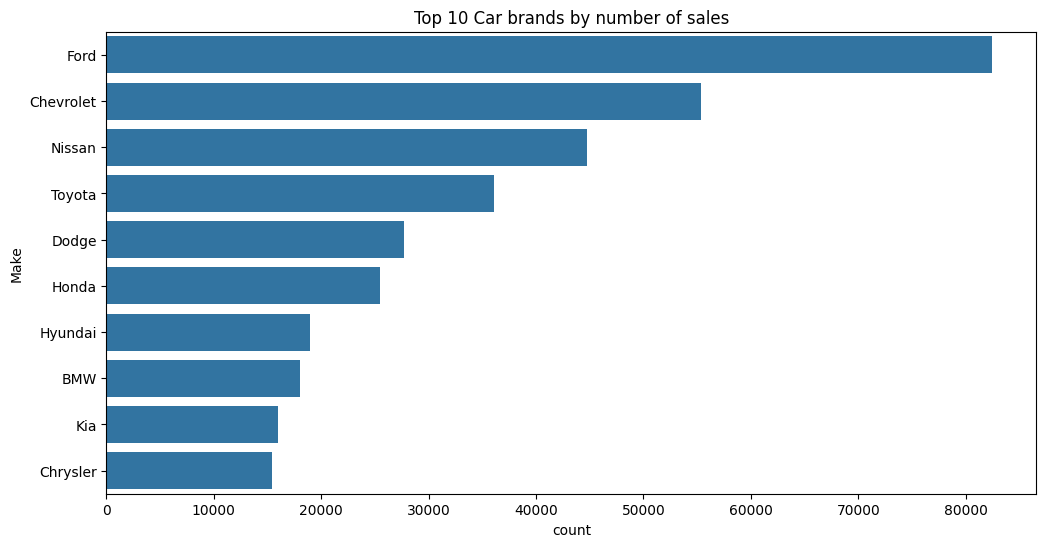

In [28]:
top_10_make = dt['make'].value_counts().head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=top_10_make.values, 
    y= top_10_make.index
)

plt.title('Top 10 Car brands by number of sales')
plt.xlabel('count')
plt.ylabel('Make')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f}',
                (width, p.get_height()/ 2.),
                ha='left', va='centre',
                xytext=(5, 0),
                textcoords='offset points'
               )
    

plt.show()

/var/folders/cn/qyffmgw97_zblr1dq_d34mz00000gn/T/ipykernel_13151/4287254541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(


ValueError: 'centre' is not a valid value for align; supported values are 'top', 'bottom', 'center', 'baseline', 'center_baseline'

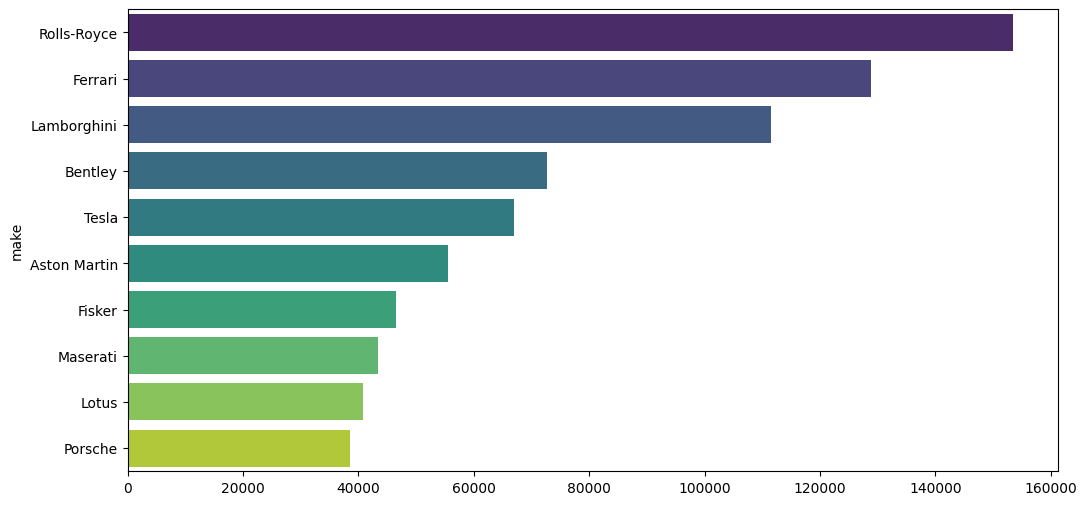

In [29]:
brand_price = dt.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
ax =sns.barplot(
    x=brand_price.values, 
    y=brand_price.index, 
    palette='viridis'
) 
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='centre',
                xytext=(5,0),
                textcoords='offsetpoint')
plt.show()